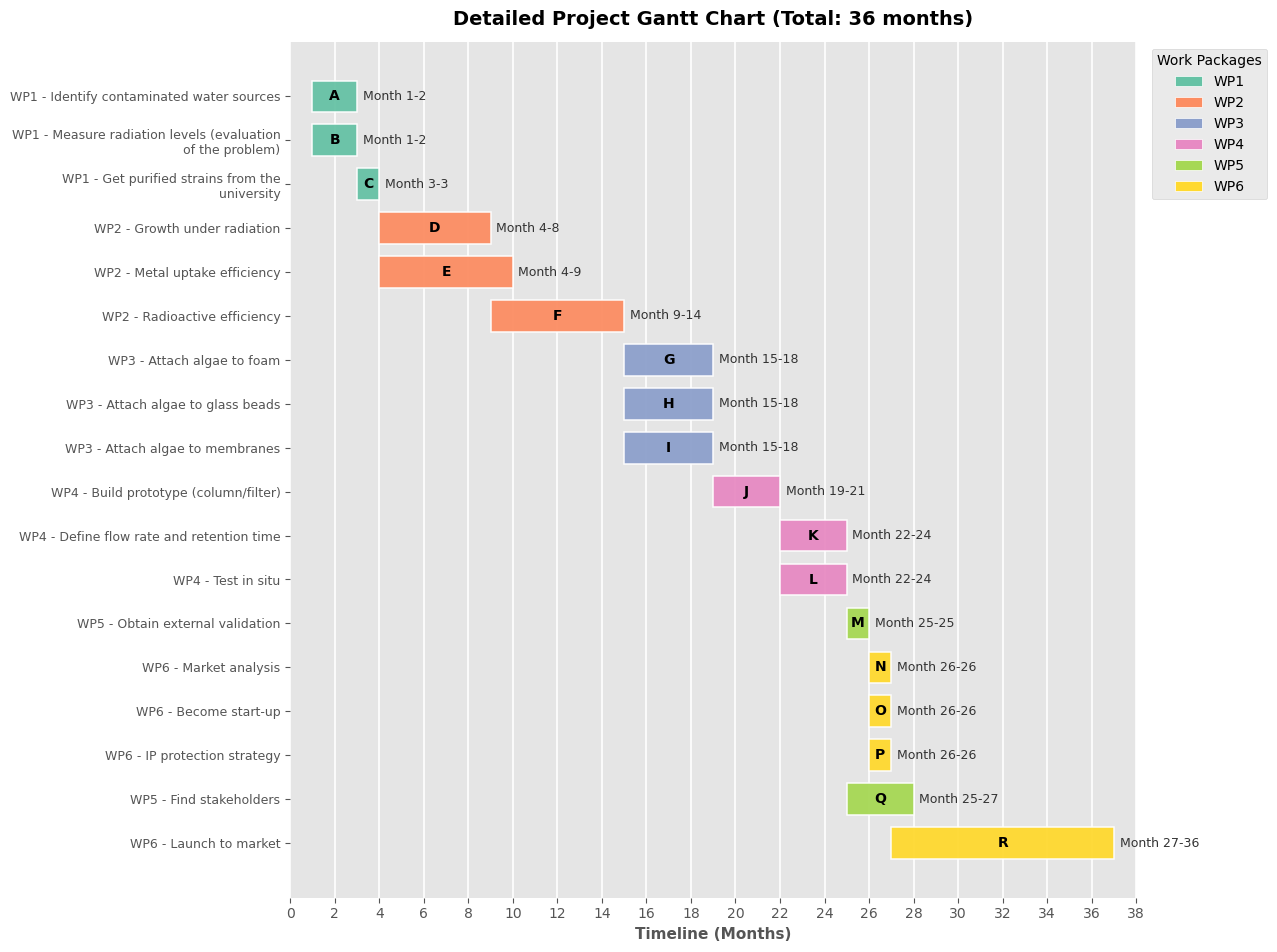

'detailed_gantt_chart_r_style.png'

In [14]:
# R-style detailed Gantt chart driven by dependency table
import textwrap

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Use a ggplot-like theme for an R-style look
plt.style.use("ggplot")

# Set this to 36 or 33 to extend the final bar (R) to your desired project end month
TARGET_FINAL_MONTH = 36

# (Letter, Activity, Duration, Predecessors, Work Package)
# WP mapping follows your project phases
tasks_data = [
    ("A", "Identify contaminated water sources", 2, [], "WP1"),
    ("B", "Measure radiation levels (evaluation of the problem)", 2, [], "WP1"),
    ("C", "Get purified strains from the university", 1, ["A"], "WP1"),
    ("D", "Growth under radiation", 5, ["C"], "WP2"),
    ("E", "Metal uptake efficiency", 6, ["C"], "WP2"),
    ("F", "Radioactive efficiency", 6, ["D"], "WP2"),
    ("G", "Attach algae to foam", 4, ["E", "F"], "WP3"),
    ("H", "Attach algae to glass beads", 4, ["E", "F"], "WP3"),
    ("I", "Attach algae to membranes", 4, ["E", "F"], "WP3"),
    ("J", "Build prototype (column/filter)", 3, ["G", "H", "I"], "WP4"),
    ("K", "Define flow rate and retention time", 3, ["J"], "WP4"),
    ("L", "Test in situ", 3, ["J", "B"], "WP4"),
    ("M", "Obtain external validation", 1, ["L"], "WP5"),
    ("N", "Market analysis", 1, ["M"], "WP6"),
    ("O", "Become start-up", 1, ["M"], "WP6"),
    ("P", "IP protection strategy", 1, ["M"], "WP6"),
    ("Q", "Find stakeholders", 3, ["K"], "WP5"),
    ("R", "Launch to market", 1, ["N", "O", "P", "K"], "WP6"),
]

# ColorBrewer Set2-inspired palette
wp_colors = {
    "WP1": "#66C2A5",
    "WP2": "#FC8D62",
    "WP3": "#8DA0CB",
    "WP4": "#E78AC3",
    "WP5": "#A6D854",
    "WP6": "#FFD92F",
}

# Build schedule from predecessors (inclusive month indexing)
remaining = {t[0]: t for t in tasks_data}
starts = {}
ends = {}

while remaining:
    progress = False
    for letter, activity, duration, preds, wp in list(remaining.values()):
        if all(p in starts for p in preds):
            start_month = 1 if not preds else max(ends[p] for p in preds) + 1
            end_month = start_month + duration - 1
            starts[letter] = start_month
            ends[letter] = end_month
            del remaining[letter]
            progress = True
    if not progress:
        raise ValueError("Circular or unresolved dependency found in task table.")

# Extend only the final task bar (R) to the requested final month (e.g., 33 or 36)
if TARGET_FINAL_MONTH is not None:
    r_start = starts["R"]
    if TARGET_FINAL_MONTH >= r_start:
        ends["R"] = TARGET_FINAL_MONTH

# Keep original display order A-R
scheduled_tasks = []
for letter, activity, duration, preds, wp in tasks_data:
    start = starts[letter]
    end = ends[letter]
    plotted_duration = end - start + 1
    scheduled_tasks.append((letter, activity, start, plotted_duration, end, wp))

# Layout tuning so labels/text fit cleanly
fig_height = max(9, len(scheduled_tasks) * 0.58)
fig, ax = plt.subplots(figsize=(18, fig_height))

for i, (letter, activity, start, duration, end, wp) in enumerate(scheduled_tasks):
    ax.barh(
        y=i,
        width=duration,
        left=start,
        color=wp_colors[wp],
        edgecolor="white",
        linewidth=1.1,
        height=0.72,
        alpha=0.95,
    )
    # Keep letter inside each bar
    ax.text(start + duration / 2, i, letter, ha="center", va="center", fontsize=10, weight="bold", color="black")
    # Right-side label: month duration only
    ax.text(
        start + duration + 0.25,
        i,
        f"Month {start}-{end}",
        ha="left",
        va="center",
        fontsize=9,
        color="#333333",
    )

# Y-axis: detailed WP labels with wrapped activity names
y_labels = [f"{t[5]} - {t[1]}" for t in scheduled_tasks]
y_labels_wrapped = ["\n".join(textwrap.wrap(lbl, width=42)) for lbl in y_labels]
ax.set_yticks(range(len(scheduled_tasks)))
ax.set_yticklabels(y_labels_wrapped, fontsize=9)
ax.invert_yaxis()

# X-axis based on final plotted duration
project_end = max(ends.values())
axis_end = project_end + 2
ax.set_xlim(0, axis_end)
ax.set_xticks(range(0, axis_end + 1, 2))
ax.set_xlabel("Timeline (Months)", fontsize=11, weight="bold")
ax.set_title(f"Detailed Project Gantt Chart (Total: {project_end} months)", fontsize=14, weight="bold", pad=12)

# Grid and spines for polished style
ax.grid(axis="x", color="white", linewidth=1.2)
ax.grid(axis="y", visible=False)
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

# WP legend outside plotting area to avoid overlap
legend_items = [Patch(facecolor=wp_colors[wp], edgecolor="white", label=wp) for wp in wp_colors]
ax.legend(handles=legend_items, title="Work Packages", loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True)

# Manual margins for best fit of wrapped y-labels and outside legend
fig.subplots_adjust(left=0.36, right=0.83, top=0.90, bottom=0.08)

file_path = "detailed_gantt_chart_r_style.png"
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

file_path

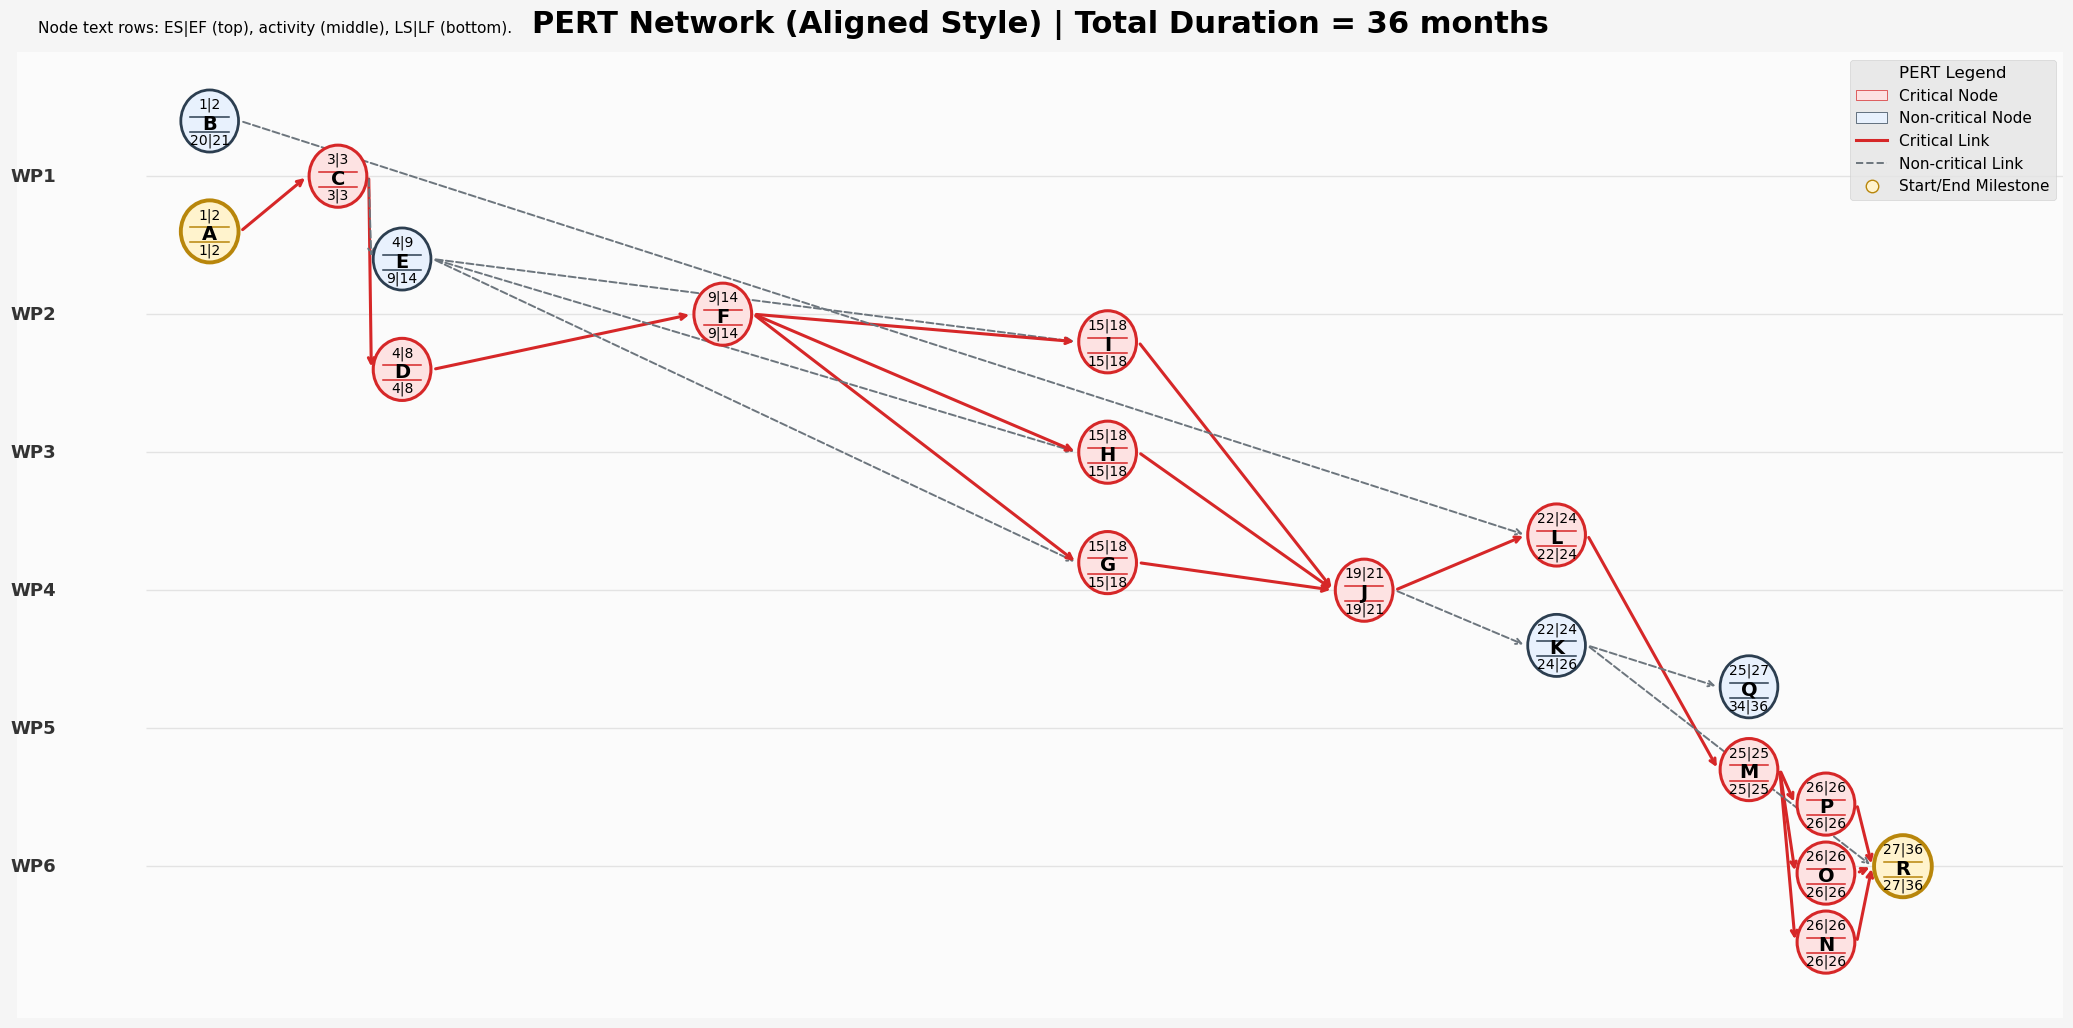

'pert_chart_improved.png'

In [23]:
# Final clear PERT chart aligned like reference style (readable labels and lines)
from collections import defaultdict

import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Build task dictionaries from existing table
duration = {t[0]: t[2] for t in tasks_data}
preds = {t[0]: list(t[3]) for t in tasks_data}
wp = {t[0]: t[4] for t in tasks_data}
letters = [t[0] for t in tasks_data]

# Keep consistency with Gantt option: stretch last task if target final month is requested
if "TARGET_FINAL_MONTH" in globals() and TARGET_FINAL_MONTH is not None:
    base_es = {}
    base_ef = {}
    unresolved = set(letters)
    while unresolved:
        progressed = False
        for n in list(unresolved):
            if all(p in base_es for p in preds[n]):
                base_es[n] = 1 if not preds[n] else max(base_ef[p] for p in preds[n]) + 1
                base_ef[n] = base_es[n] + duration[n] - 1
                unresolved.remove(n)
                progressed = True
        if not progressed:
            raise ValueError("Dependency cycle found.")
    if TARGET_FINAL_MONTH >= base_es["R"]:
        duration["R"] = TARGET_FINAL_MONTH - base_es["R"] + 1

# Successor map
succ = defaultdict(list)
for n in letters:
    for p in preds[n]:
        succ[p].append(n)

# Forward pass (ES, EF)
ES = {}
EF = {}
unresolved = set(letters)
while unresolved:
    progressed = False
    for n in list(unresolved):
        if all(p in ES for p in preds[n]):
            ES[n] = 1 if not preds[n] else max(EF[p] for p in preds[n]) + 1
            EF[n] = ES[n] + duration[n] - 1
            unresolved.remove(n)
            progressed = True
    if not progressed:
        raise ValueError("Dependency cycle found.")

project_end = max(EF.values())

# Backward pass (LS, LF)
LS = {}
LF = {}
unresolved = set(letters)
while unresolved:
    progressed = False
    for n in list(unresolved):
        if not succ[n]:
            LF[n] = project_end
            LS[n] = LF[n] - duration[n] + 1
            unresolved.remove(n)
            progressed = True
        elif all(s in LS for s in succ[n]):
            LF[n] = min(LS[s] for s in succ[n]) - 1
            LS[n] = LF[n] - duration[n] + 1
            unresolved.remove(n)
            progressed = True
    if not progressed:
        raise ValueError("Dependency cycle found.")

slack = {n: LS[n] - ES[n] for n in letters}
critical_nodes = {n for n in letters if slack[n] == 0}

# Aligned layout close to your reference image: x by time, y in fixed WP rows
wp_order = ["WP1", "WP2", "WP3", "WP4", "WP5", "WP6"]
wp_lane_y = {"WP1": 10, "WP2": 8, "WP3": 6, "WP4": 4, "WP5": 2, "WP6": 0}

# For same WP and similar x, spread vertically a bit to avoid overlap
by_wp = defaultdict(list)
for n in letters:
    by_wp[wp[n]].append(n)
for w in wp_order:
    by_wp[w].sort(key=lambda n: (ES[n], n))

pos = {}
for w in wp_order:
    buckets = defaultdict(list)
    for n in by_wp[w]:
        buckets[ES[n]].append(n)
    for x_key, group in buckets.items():
        if len(group) == 1:
            pos[group[0]] = (ES[group[0]], wp_lane_y[w])
        else:
            spread = 1.6
            start_offset = spread * (len(group) - 1) / 2
            for idx, n in enumerate(group):
                pos[n] = (ES[n], wp_lane_y[w] - start_offset + idx * spread)

# Manual alignment for final cluster to avoid crowding (matches reference feel)
pos["M"] = (25.0, 1.4)
pos["Q"] = (25.0, 2.6)
pos["N"] = (26.2, -1.1)
pos["O"] = (26.2, -0.1)
pos["P"] = (26.2, 0.9)
pos["R"] = (27.4, 0.0)

fig, ax = plt.subplots(figsize=(22, 11.5))
fig.patch.set_facecolor("#f5f5f5")
ax.set_facecolor("#fbfbfb")

# subtle lane guides
for w in wp_order:
    y = wp_lane_y[w]
    ax.hlines(y, 0, project_end + 1, colors="#e3e3e3", linewidth=1.0, zorder=0)
    ax.text(-1.4, y, w, ha="right", va="center", fontsize=13, fontweight="bold", color="#333333")

# Draw edges first (straight and clear)
for n in letters:
    x2, y2 = pos[n]
    for p in preds[n]:
        x1, y1 = pos[p]
        is_critical_edge = p in critical_nodes and n in critical_nodes and ES[n] == EF[p] + 1
        edge_color = "#d62728" if is_critical_edge else "#6c757d"
        edge_style = "-" if is_critical_edge else "--"
        edge_width = 2.2 if is_critical_edge else 1.4

        ax.annotate(
            "",
            xy=(x2 - 0.48, y2),
            xytext=(x1 + 0.48, y1),
            arrowprops=dict(arrowstyle="->", color=edge_color, lw=edge_width, linestyle=edge_style),
            zorder=1,
        )

# Draw nodes as clean circles (reference-like)
for n in letters:
    x, y = pos[n]
    is_start_or_end = n in {"A", "R"}
    is_critical = n in critical_nodes

    if is_start_or_end:
        face = "#fff3cd"
        edge = "#b8860b"
        lw = 2.8
    elif is_critical:
        face = "#fde2e2"
        edge = "#d62728"
        lw = 2.2
    else:
        face = "#e8f1fd"
        edge = "#2c3e50"
        lw = 2.0

    node = Circle((x, y), radius=0.45, facecolor=face, edgecolor=edge, linewidth=lw, zorder=3)
    ax.add_patch(node)
    ax.plot([x - 0.30, x + 0.30], [y + 0.06, y + 0.06], color=edge, linewidth=1.1, zorder=4)
    ax.plot([x - 0.30, x + 0.30], [y - 0.16, y - 0.16], color=edge, linewidth=1.1, zorder=4)

    # top: ES|EF, middle: activity letter, bottom: LS|LF
    ax.text(x, y + 0.24, f"{ES[n]}|{EF[n]}", ha="center", va="center", fontsize=10, zorder=5)
    ax.text(x, y - 0.04, n, ha="center", va="center", fontsize=14, fontweight="bold", zorder=5)
    ax.text(x, y - 0.28, f"{LS[n]}|{LF[n]}", ha="center", va="center", fontsize=10, zorder=5)

# Remove bottom timeline completely
ax.set_xticks([])
ax.set_xlabel("")
ax.set_yticks([])

ax.set_xlim(-2, max(x for x, _ in pos.values()) + 2.5)
ax.set_ylim(-2.2, 11.8)
ax.set_title(f"PERT Network (Aligned Style) | Total Duration = {project_end} months", fontsize=22, fontweight="bold", pad=14)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

# Legend
legend_handles = [
    mpatches.Patch(facecolor="#fde2e2", edgecolor="#d62728", label="Critical Node"),
    mpatches.Patch(facecolor="#e8f1fd", edgecolor="#2c3e50", label="Non-critical Node"),
    mlines.Line2D([], [], color="#d62728", linestyle="-", linewidth=2.2, label="Critical Link"),
    mlines.Line2D([], [], color="#6c757d", linestyle="--", linewidth=1.4, label="Non-critical Link"),
    mlines.Line2D([], [], color="#b8860b", marker="o", markersize=9, linestyle="None", markerfacecolor="#fff3cd", label="Start/End Milestone"),
]
ax.legend(handles=legend_handles, loc="upper right", frameon=True, title="PERT Legend", fontsize=11, title_fontsize=12)

ax.text(0.01, 1.02, "Node text rows: ES|EF (top), activity (middle), LS|LF (bottom).", transform=ax.transAxes, fontsize=11)

fig.subplots_adjust(left=0.05, right=0.98, top=0.90, bottom=0.06)
pert_file_path = "pert_chart_improved.png"
plt.savefig(pert_file_path, dpi=500, bbox_inches="tight")
plt.show()

pert_file_path